In [97]:
!pip install PyPDF2


In [98]:
!pip install pdfplumber

In [99]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



# IMPORT LIBRARY


In [100]:

import nltk
import re
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import pdfplumber

from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.util import ngrams
from collections import Counter, defaultdict

nltk.download("punkt")
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

#FUNGSI EKSTRAK PDF

In [101]:
def extract_pdf(path):
    text = ""
    with pdfplumber.open(path) as pdf:
        for page in pdf.pages:
            content = page.extract_text()
            if content:
                text += content + " "
    return text.lower()


#NORMALISASI TEKS

In [102]:
def normalize_text(text):
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^a-zA-Z_\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = re.sub(r"\b[a-zA-Z]\b", " ", text)
    return text

#EKSTRAK MULTIWORD KEYWORD OTOMATIS (BIGRAM)

In [103]:
def extract_auto_multiword_keywords(text, top_n=30, min_freq=3):
    words = word_tokenize(text)

    bigrams = list(ngrams(words, 2))
    freq = Counter(bigrams)

    candidates = [
        " ".join(bg)
        for bg, f in freq.items()
        if f >= min_freq
    ]

    candidates = sorted(
        candidates,
        key=lambda x: freq[tuple(x.split())],
        reverse=True
    )

    return candidates[:top_n]



# GABUNGKAN MULTIWORD DENGAN REG

In [104]:
def merge_multiword_keywords_regex(text, keywords):
    for kw in keywords:
        token = kw.replace(" ", "_")
        pattern = re.compile(r"\b" + kw.replace(" ", r"\s+") + r"\b", re.IGNORECASE)
        text = pattern.sub(token, text)
    return text

#LOAD PDF

In [105]:
pdf_path = "/content/drive/MyDrive/PPW/16.+Florensa+(112-117).pdf"
raw_text = extract_pdf(pdf_path)


#NORMALISASI AWAL

In [106]:
text_norm = normalize_text(raw_text)


#AMBIL KEYWORD MULTIWORD OTOMATIS

In [107]:
keywords_multi = extract_auto_multiword_keywords(
    text_norm,
    top_n=30,
    min_freq=3
)

print("\n=== KEYWORD MULTIWORD OTOMATIS ===")
for kw in keywords_multi:
    print("-", kw)



=== KEYWORD MULTIWORD OTOMATIS ===
- kesehatan mental
- kesehatan jiwa
- mental emosional
- pada remaja
- masalah kesehatan
- perilaku prososial
- sebanyak orang
- https doi
- doi org
- emosional remaja
- gambaran kesehatan
- penelitian ini
- teman sebaya
- et al
- menunjukkan bahwa
- frekuensi presentase
- florensa nurul
- nurul hidayah
- hidayah lintang
- lintang sari
- sari fajar
- fajar yousrihatin
- yousrihatin wulida
- wulida litaqia
- mental health
- kota pontianak
- litaqia gambaran
- remaja memiliki
- masalah perilaku
- masalah emosi


#GABUNGKAN MULTIWORD KE TEKS

In [108]:
merged_text = merge_multiword_keywords_regex(raw_text, keywords_multi)

# normalisasi ulang
text = normalize_text(merged_text)


#TOKENISASI

In [109]:
sentences = sent_tokenize(text)
tokenized = [word_tokenize(s) for s in sentences]


#COOCCURRENCE MATRIX

In [110]:
def build_cooccurrence(tokenized_sentences, window_size=2):
    cooc = defaultdict(Counter)
    for sentence in tokenized_sentences:
        for i, word in enumerate(sentence):
            window = sentence[i+1:i+1+window_size]
            for w in window:
                if w != word:
                    cooc[word][w] += 1
                    cooc[w][word] += 1
    return cooc

co_matrix = build_cooccurrence(tokenized)

#GRAPH 1 (SEMUA KATA)

In [111]:
def build_graph(cooc, min_weight=2):
    G = nx.Graph()
    for w, neigh in cooc.items():
        for n, freq in neigh.items():
            if freq >= min_weight:
                G.add_edge(w, n, weight=freq)
    return G

G_single = build_graph(co_matrix)

#GRAPH 2 (MULTIWORD + TETANGGA)

In [112]:
keyword_nodes = [kw.replace(" ", "_") for kw in keywords_multi]
existing_keywords = [n for n in G_single.nodes() if n in keyword_nodes]

neighbors = set()
for kw in existing_keywords:
    neighbors.update(G_single.neighbors(kw))

subgraph_nodes = set(existing_keywords) | neighbors
G_multiword = G_single.subgraph(subgraph_nodes).copy()

print("\nGraph 2")
print("Jumlah Node:", len(G_multiword.nodes()))
print("Jumlah Edge:", len(G_multiword.edges()))


Graph 2
Jumlah Node: 74
Jumlah Edge: 165


#VISUALISASI GRAPH

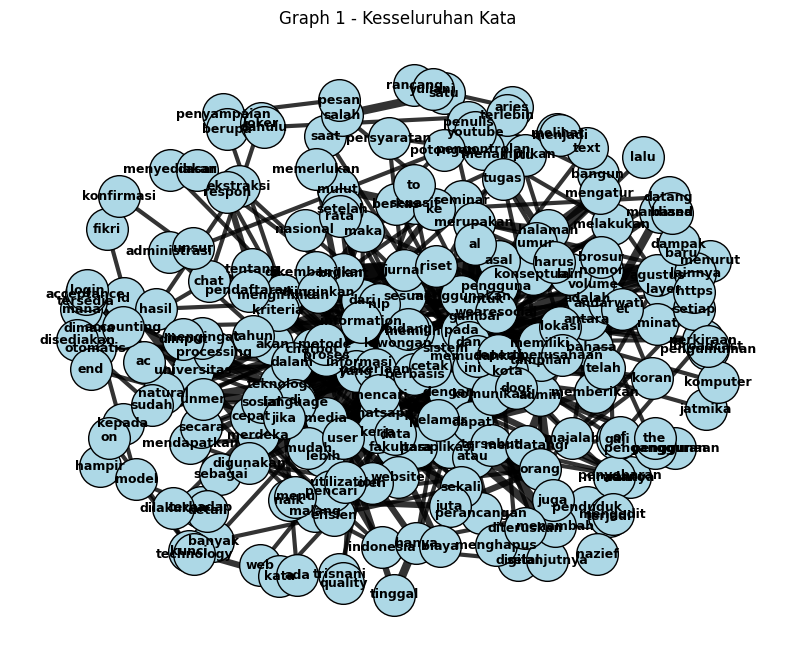

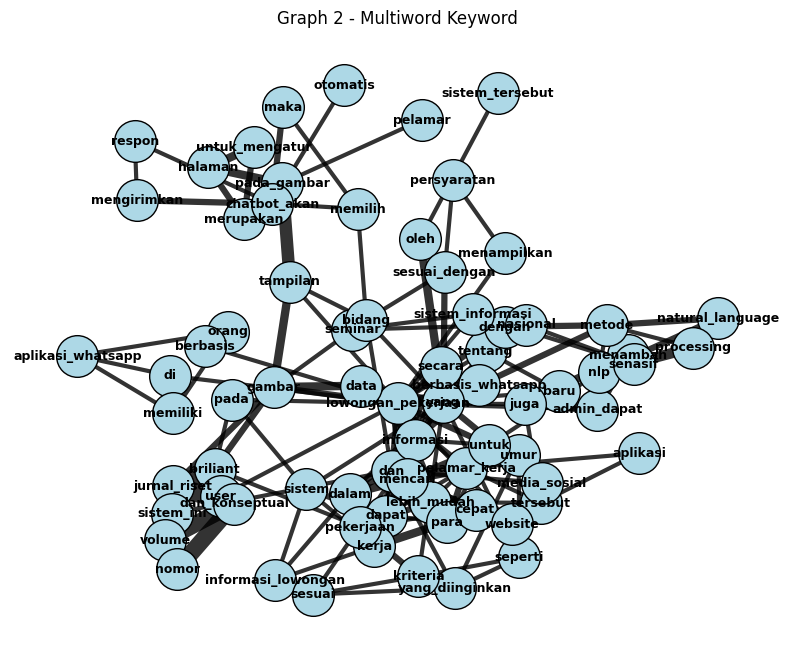

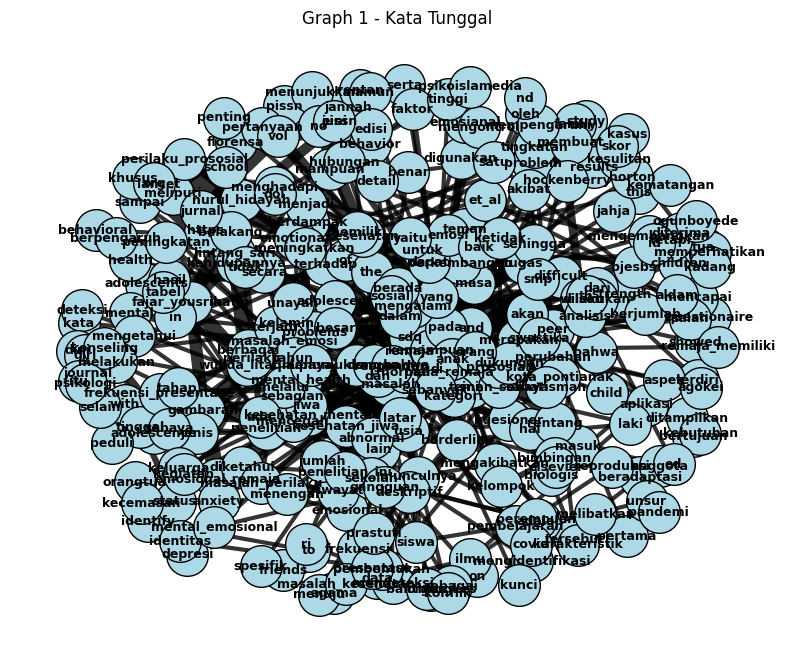

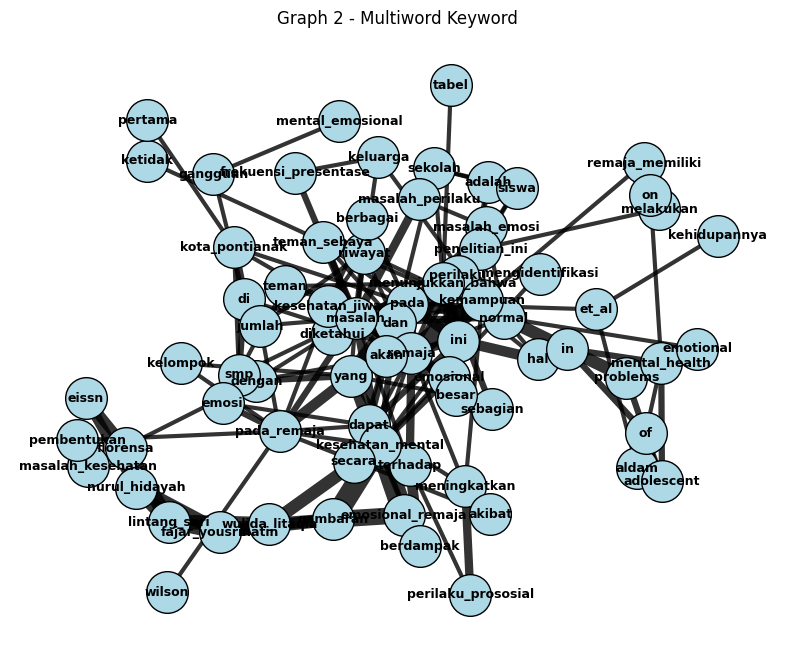

In [113]:
def draw_graph(G, title):
    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G, k=0.65, seed=42)
    weights = [G[u][v]['weight'] for u, v in G.edges()]

    nx.draw_networkx_nodes(
        G, pos,
        node_size=900,
        node_color='lightblue',
        edgecolors='black'
    )

    nx.draw_networkx_edges(
        G, pos,
        width=[w * 1.5 for w in weights],
        alpha=0.8
    )

    nx.draw_networkx_labels(
        G, pos,
        font_size=9,
        font_weight='bold'
    )

    plt.title(title)
    plt.axis("off")
    plt.show()

draw_graph(G_single, "Graph 1 - Kata Tunggal")
draw_graph(G_multiword, "Graph 2 - Multiword Keyword")


In [114]:
# ============================================================
# PAGE RANK
# ============================================================
pagerank_single = nx.pagerank(G_single)
pagerank_multi = nx.pagerank(G_multiword)

print("\n=== PAGE RANK GRAPH 1 (TOP 20) ===")
for k, v in sorted(pagerank_single.items(), key=lambda x: -x[1])[:20]:
    print(f"{k:25s} : {v:.5f}")

print("\n=== PAGE RANK GRAPH 2 (TOP 20) ===")
for k, v in sorted(pagerank_multi.items(), key=lambda x: -x[1])[:20]:
    print(f"{k:25s} : {v:.5f}")


=== PAGE RANK GRAPH 1 (TOP 20) ===
yang                      : 0.03969
remaja                    : 0.03962
pada                      : 0.02803
dan                       : 0.02653
masalah                   : 0.02448
normal                    : 0.01202
orang                     : 0.01192
and                       : 0.01164
dalam                     : 0.01106
kesehatan_mental          : 0.01091
of                        : 0.01038
the                       : 0.00930
untuk                     : 0.00889
dengan                    : 0.00884
kemampuan                 : 0.00884
https                     : 0.00871
ini                       : 0.00863
abnormal                  : 0.00849
dapat                     : 0.00843
pada_remaja               : 0.00823

=== PAGE RANK GRAPH 2 (TOP 20) ===
masalah                   : 0.05554
remaja                    : 0.05298
pada                      : 0.04487
dan                       : 0.03846
yang                      : 0.03659
kesehatan_mental          : 

#Tampilan menggunakan gradio

In [115]:
# ============================================================
# 8. VISUALISASI GRAPH
# ============================================================
def draw_graph(G, title):
    fig, ax = plt.subplots(figsize=(9, 7))

    pos = nx.spring_layout(G, k=0.6, seed=42)
    weights = [G[u][v]["weight"] for u, v in G.edges()]

    nx.draw_networkx_nodes(
        G, pos,
        node_size=850,
        node_color="lightblue",
        edgecolors="black",
        ax=ax
    )

    nx.draw_networkx_edges(
        G, pos,
        width=[w * 1.3 for w in weights],
        alpha=0.8,
        ax=ax
    )

    nx.draw_networkx_labels(
        G, pos,
        font_size=8,
        font_weight="bold",
        ax=ax
    )

    ax.set_title(title, fontsize=13)
    ax.axis("off")

    plt.close(fig)
    return fig



# ============================================================
# 9. FUNGSI UTAMA (GRAPH 1 & GRAPH 2 TERPISAH)
# ============================================================
def process_pdf(file):
    raw_text = extract_pdf(file.name)

    # ========================================================
    # GRAPH 1 : KATA TUNGGAL (TANPA MULTIWORD)
    # ========================================================
    text_single = normalize_text(raw_text)
    sent_single = sent_tokenize(text_single)
    tok_single = [word_tokenize(s) for s in sent_single]

    co_single = build_cooccurrence(tok_single)
    G_single = build_graph(co_single)

    pr_single = nx.pagerank(G_single)
    df_pr_single = (
        pd.DataFrame(pr_single.items(), columns=["Kata", "PageRank"])
        .sort_values("PageRank", ascending=False)
        .reset_index(drop=True)
    )

    fig1 = draw_graph(G_single, "Graph 1 - Seluruh Kata (Tanpa Multiword)")

    # ========================================================
    # GRAPH 2 : MULTIWORD KEYWORD
    # ========================================================
    text_norm = normalize_text(raw_text)
    keywords_multi = extract_auto_multiword_keywords(text_norm)

    merged_text = merge_multiword_keywords_regex(raw_text, keywords_multi)
    text_multi = normalize_text(merged_text)

    sent_multi = sent_tokenize(text_multi)
    tok_multi = [word_tokenize(s) for s in sent_multi]

    co_multi = build_cooccurrence(tok_multi)
    G_multi_full = build_graph(co_multi)

    keyword_nodes = [kw.replace(" ", "_") for kw in keywords_multi]
    existing_kw = [n for n in G_multi_full.nodes() if n in keyword_nodes]

    neighbors = set()
    for kw in existing_kw:
        neighbors.update(G_multi_full.neighbors(kw))

    sub_nodes = set(existing_kw) | neighbors
    G_multi = G_multi_full.subgraph(sub_nodes).copy()

    pr_multi = nx.pagerank(G_multi)
    df_pr_multi = (
        pd.DataFrame(pr_multi.items(), columns=["Multiword", "PageRank"])
        .sort_values("PageRank", ascending=False)
        .reset_index(drop=True)
    )

    fig2 = draw_graph(G_multi, "Graph 2 - Multiword Keyword")

    return fig1, df_pr_single, fig2, df_pr_multi


In [116]:
# ============================================================
# GRADIO INTERFACE (SATU APLIKASI)
# ============================================================
interface = gr.Interface(
    fn=process_pdf,
    inputs=gr.File(label="Upload PDF Jurnal"),
    outputs=[
        gr.Plot(label="Graph 1 - Seluruh Kata"),
        gr.Dataframe(label="PageRank Graph 1"),
        gr.Plot(label="Graph 2 - Multiword Keyword"),
        gr.Dataframe(label="PageRank Graph 2"),
    ],
    title="Analisis Co-occurrence & PageRank Jurnal Ilmiah",
    description=(
        "Graph 1 dibangun dari teks tanpa penggabungan multiword "
        "untuk merepresentasikan hubungan kata secara murni, "
        "sedangkan Graph 2 dibangun dari teks hasil penggabungan "
        "multiword untuk merepresentasikan hubungan konseptual."
    )
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8b254033c5a9f390ee.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### link Hugging face: https://huggingface.co/spaces/fediarta19/wordgraph1